## Note book on exploratory data analysis
Exploratory data analysis is an essential component of the machine learning pipeline. There is a saying in ML that **"garbage in , garbage out"**. To ensure that we inject the cleanest and most potent dataframe in our machine learning model, we must first explore the dataset to indentify and extract all meaningful information and trend. 

In this notebook I am trying to present some demonstration on, how barchart, scatter plot,line chart and other charts can help us discover meaningful insight about the data.

For this we will be exploring three datasets,Los ,[Angeles Museum Visitors](https://www.kaggle.com/alexisbcook/data-for-datavis?select=museum_visitors.csv), [FLight_delays dataset from the US Department of Transportation](https://www.kaggle.com/alexisbcook/data-for-datavis?select=flight_delays.csv)  and the [candy_dataset](https://www.kaggle.com/alexisbcook/data-for-datavis?select=candy.csv). 

We will explore these datasets using 
* pandas, 
* matplotlib and 
* seaborn library.



In [1]:

# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/data-for-datavis/fifa.csv
/kaggle/input/data-for-datavis/ign_scores.csv
/kaggle/input/data-for-datavis/spotify.csv
/kaggle/input/data-for-datavis/flight_delays.csv
/kaggle/input/data-for-datavis/iris_setosa.csv
/kaggle/input/data-for-datavis/insurance.csv
/kaggle/input/data-for-datavis/cancer_b.csv
/kaggle/input/data-for-datavis/cancer_m.csv
/kaggle/input/data-for-datavis/iris_virginica.csv
/kaggle/input/data-for-datavis/iris.csv
/kaggle/input/data-for-datavis/iris_versicolor.csv
/kaggle/input/data-for-datavis/candy.csv
/kaggle/input/data-for-datavis/museum_visitors.csv


## Line Chart
A line chart is often used to visualize a trend in data over intervals of time – a time series – thus the line is often drawn chronologically.As usual the first step of data exploration is to read the dataset as a pandas dataframa. So, lts do it..Before that lets import matplotlib and and seaborn

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Now lets read the museum dataset.
museum_path='../input/data-for-datavis'
museum_filepath='museum_visitors.csv'
museum_file=os.path.join(museum_path,museum_filepath)
museum_data=pd.read_csv(museum_file,index_col=['Date'],parse_dates=True)

This dataset has data for monthly museum visitor for five museums from jan, 2014 till 2018.
Now, since we have the datafame, lets have a look at some rows of the dataset. 

In [3]:
museum_data.head(5)

,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center
Date,,,,
2014-01-01,24778,4486,1581,6602
2014-02-01,18976,4172,1785,5029
2014-03-01,25231,7082,3229,8129
2014-04-01,26989,6756,2129,2824
2014-05-01,36883,10858,3676,10694


In [4]:
# Lets have a close look at the visitor data for one of the museums
museum_data['Avila Adobe'][museum_data.index.year==2018]

Date
2018-01-01    16265
2018-02-01    14718
2018-03-01    19001
2018-04-01    18966
2018-05-01    25173
2018-06-01    22171
2018-07-01    23136
2018-08-01    20815
2018-09-01    21020
2018-10-01    19280
2018-11-01    17163
Name: Avila Adobe, dtype: int64

## Introduction to Seaborn Library
Seaborn is a library for making statistical graphics in Python. It builds on top of matplotlib and integrates closely with pandas data structures.

Seaborn helps you explore and understand your data. Its one of my favorite library for data exploration

* We will now plot a line chart to visualize the trend of no of visitors for each of the museums for the period 2014 till 2018.  

* Lets see if the plot can highlight any trend and spike in visitor number for a month etc

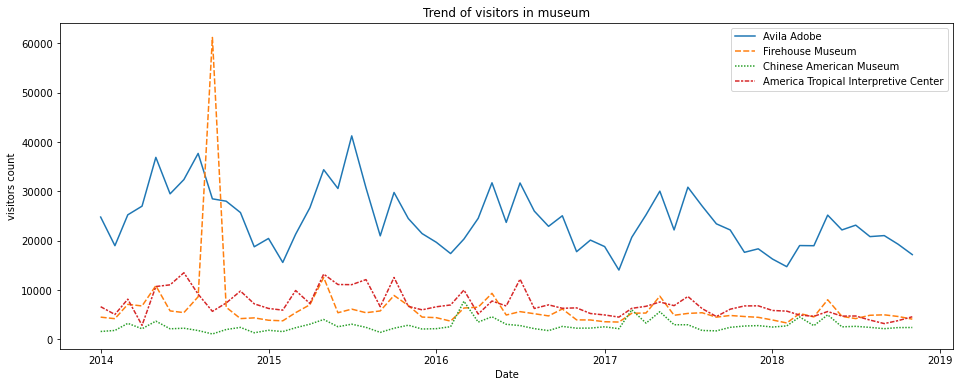

In [5]:
plt.figure(figsize=(16,6))
plt.title('Trend of visitors in museum')
plt.xlabel('Date')
plt.ylabel('visitors count')
sns.lineplot(data=museum_data)

## Spike in visitors for Firehouse Museum
As we can see that for the Firehouse Museum, there is a noticiably **high spike in number of visitors in  August, 2014,** where the visitor count exceeded 6000 as compared to an avarage count of 1000  visitors for Firehouse museum in August. We can then use this information to look for any specific event during this time to dig deep.

## Lets have a close look at visitor counts for Avila Adobe museum

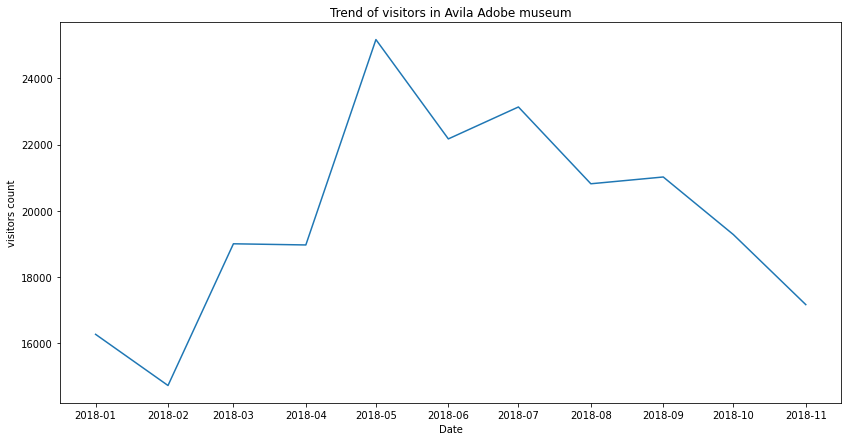

In [6]:
plt.figure(figsize=(14,7))
plt.title('Trend of visitors in Avila Adobe museum')
plt.xlabel('Date')
plt.ylabel('visitors count')
sns.lineplot(data=museum_data['Avila Adobe'][museum_data.index.year==2018])

We can see from the above plot that no of visitors are higher between the months May and September. In other words people do not prefer to visit museums in the winter. We can dig deep in each of this observatin, however, we will keep the scope of this notebook limited to discover any trend in the data.

## Lets explore some  Heatmaps

We will  work with a dataset from the US Department of Transportation that tracks flight delays. The dataset contains average delay in minutes each  month per flight for 14 airlines. Lets explore this data to find out any pattern in av. delays for each airline. We can find out the most punctual and the worst airline as far as timeliness is concerned.Digging deep we may find out what are the factor that effects the delay or timely departure and arival of a flight.

In [7]:
file_dir='../input/data-for-datavis'
file_name='flight_delays.csv'
file=os.path.join(file_dir,file_name)
flight_data=pd.read_csv(file)
flight_data.head(12)

,Month,AA,AS,B6,DL,EV,F9,HA,MQ,NK,OO,UA,US,VX,WN
0,1,6.955843,-0.320888,7.347281,-2.043847,8.537497,18.357238,3.512640,18.164974,11.398054,10.889894,6.352729,3.107457,1.420702,3.389466
1,2,7.530204,-0.782923,18.657673,5.614745,10.417236,27.424179,6.029967,21.301627,16.474466,9.588895,7.260662,7.114455,7.784410,3.501363
2,3,6.693587,-0.544731,10.741317,2.077965,6.730101,20.074855,3.468383,11.018418,10.039118,3.181693,4.892212,3.330787,5.348207,3.263341
3,4,4.931778,-3.009003,2.780105,0.083343,4.821253,12.640440,0.011022,5.131228,8.766224,3.223796,4.376092,2.660290,0.995507,2.996399
4,5,5.173878,-1.716398,-0.709019,0.149333,7.724290,13.007554,0.826426,5.466790,22.397347,4.141162,6.827695,0.681605,7.102021,5.680777
5,6,8.191017,-0.220621,5.047155,4.419594,13.952793,19.712951,0.882786,9.639323,35.561501,8.338477,16.932663,5.766296,5.779415,10.743462
6,7,3.870440,0.377408,5.841454,1.204862,6.926421,14.464543,2.001586,3.980289,14.352382,6.790333,10.262551,NaN,7.135773,10.504942
7,8,3.193907,2.503899,9.280950,0.653114,5.154422,9.175737,7.448029,1.896565,20.519018,5.606689,5.014041,NaN,5.106221,5.532108
8,9,-1.432732,-1.813800,3.539154,-3.703377,0.851062,0.978460,3.696915,-2.167268,8.000101,1.530896,-1.794265,NaN,0.070998,-1.336260
9,10,-0.580930,-2.993617,3.676787,-5.011516,2.303760,0.082127,0.467074,-3.735054,6.810736,1.750897,-2.456542,NaN,2.254278,-0.688851


## explore and clean the data
The dataset looks like a matrix where on x-axis we have the airlines and on y-axis we have the months. On the intersection point of these two axis we will find the av delay for that airline in that month. For this type of scenario heatmaps are the appropriaten choice. So, lets plot one to explore the delays..
### Data cleaning:
* The US airline data column **has many null values**. First we will have to handle these values before we can plot the data. We will here, **replace the null values with the mean value from the other data points in that column**.In practice, there are other more effective methods to handle null values.
* To find out null values we cn use pandas isnull() method


In [8]:
# The below line of code will give us the null values in the US column
flight_data[pd.isnull(flight_data.US)]

,Month,AA,AS,B6,DL,EV,F9,HA,MQ,NK,OO,UA,US,VX,WN
6,7,3.870440,0.377408,5.841454,1.204862,6.926421,14.464543,2.001586,3.980289,14.352382,6.790333,10.262551,NaN,7.135773,10.504942
7,8,3.193907,2.503899,9.280950,0.653114,5.154422,9.175737,7.448029,1.896565,20.519018,5.606689,5.014041,NaN,5.106221,5.532108
8,9,-1.432732,-1.813800,3.539154,-3.703377,0.851062,0.978460,3.696915,-2.167268,8.000101,1.530896,-1.794265,NaN,0.070998,-1.336260
9,10,-0.580930,-2.993617,3.676787,-5.011516,2.303760,0.082127,0.467074,-3.735054,6.810736,1.750897,-2.456542,NaN,2.254278,-0.688851
10,11,0.772630,-1.916516,1.418299,-3.175414,4.415930,11.164527,-2.719894,0.220061,7.543881,4.925548,0.281064,NaN,0.116370,0.995684
11,12,4.149684,-1.846681,13.839290,2.504595,6.685176,9.346221,-1.706475,0.662486,12.733123,10.947612,7.012079,NaN,13.498720,6.720893


In [9]:
mean=flight_data['US'].mean()
flight_data.fillna(value=mean,inplace=True)

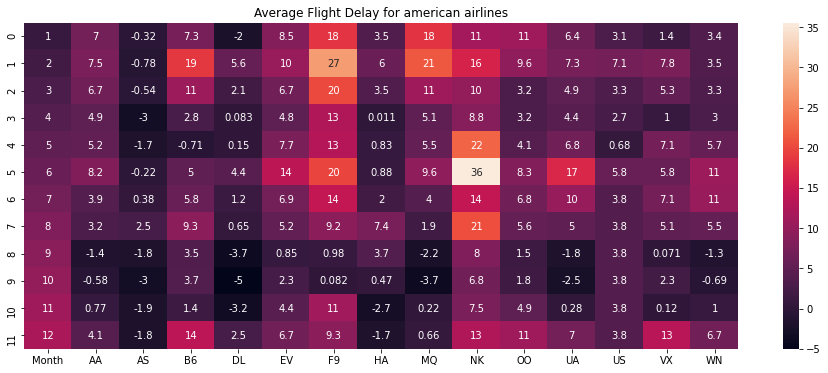

In [10]:
# Lets find the average arrival delay for spirit airlines flights. Code=NK
plt.figure(figsize=(16,6))
plt.title('Average Flight Delay for american airlines')
# plt.xticks(rotation='vertical')
plt.ylabel('months==>')
sns.heatmap(data=flight_data,annot=True)

The lighter shades represents data points where there are higher delays. The darker shaded boxes point towards timely arrivals. So, we would like to select a flight from an airline which has more darker boxes in our plot

## Scatter plot and candy  dataset
In this dataset we have ingrdients, pricing and popularity attributes for some 83 different candy bars.Some important columns in the dataset are..
*  **'competitorname'** contains the name of the candy bar.
* **the next 9 columns** (from 'chocolate' to 'pluribus') describe the candy. For instance, rows with chocolate candies have "Yes" in the 'chocolate' column (and candies without chocolate have "No" in the same column).
* **'sugarpercent'** provides some indication of the amount of sugar, where higher values signify higher sugar content.
* **'pricepercent'** shows the price per unit, relative to the other candies in the dataset.
* **'winpercent'** is calculated from the survey results; higher values indicate that the candy was more popular with survey respondents.

In [11]:
file_dir='../input/data-for-datavis'
file_name='candy.csv'
file=os.path.join(file_dir,file_name)
candy_data=pd.read_csv(file)
candy_data.head()

,id,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,0,100 Grand,Yes,No,Yes,No,No,Yes,No,Yes,No,0.732,0.860,66.971725
1,1,3 Musketeers,Yes,No,No,No,Yes,No,No,Yes,No,0.604,0.511,67.602936
2,2,Air Heads,No,Yes,No,No,No,No,No,No,No,0.906,0.511,52.341465
3,3,Almond Joy,Yes,No,No,Yes,No,No,No,Yes,No,0.465,0.767,50.347546
4,4,Baby Ruth,Yes,No,Yes,Yes,Yes,No,No,Yes,No,0.604,0.767,56.914547


In [12]:
# Which candybar has the highest winpercent
candy_data[candy_data['winpercent']==candy_data['winpercent'].max()]

,id,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
50,50,Reese's Peanut Butter cup,Yes,No,No,Yes,No,No,No,No,No,0.72,0.651,84.18029


In [13]:
# Which candybar has the highest percentage of sugar
candy_data[candy_data['sugarpercent']==candy_data['sugarpercent'].max()]

,id,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
52,52,Reese's stuffed with pieces,Yes,No,No,Yes,No,No,No,No,No,0.988,0.651,72.887901


Does it have any **relationship between 'sugarpercent' (on the horizontal x-axis) and 'winpercent' (on the vertical y-axis).**



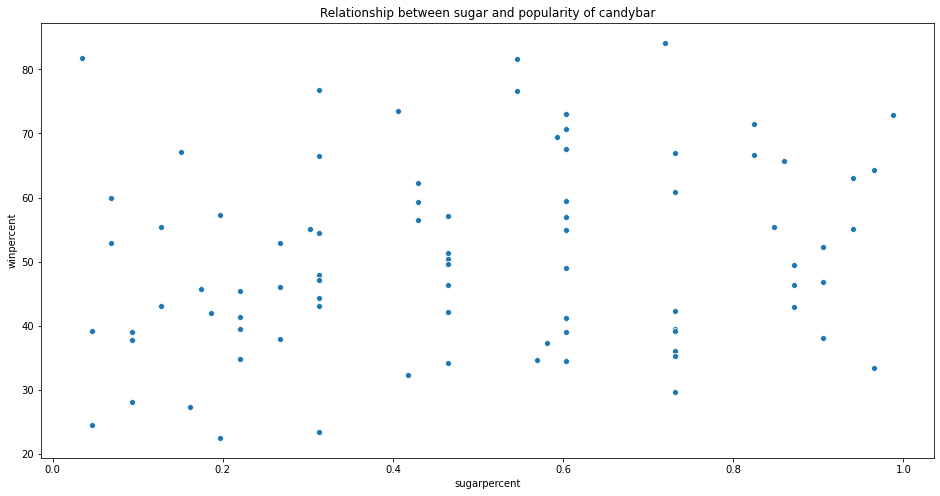

In [14]:
plt.figure(figsize=(16,8))
plt.title('Relationship between sugar and popularity of candybar')
sns.scatterplot(data=candy_data, x='sugarpercent', y='winpercent')

We do not se any correlation between sugar and popularity
 lets confirm it by plottting a regression line. Regression line are helpful in finding correlation

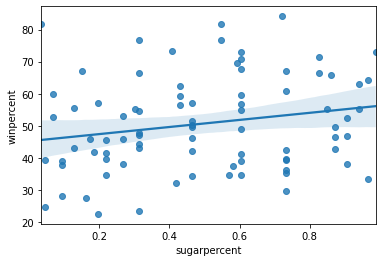

In [15]:
sns.regplot(data=candy_data, x='sugarpercent', y='winpercent')

In the previous plot we can see a slight correlation between sugar and popularity. Now, lets add the **chocolate** feature and try to find out **how it is related to popularity** of a candybar

* we are using the hue to colorcode
* we are also using lmplot instead of the scatterplot. Its a version of scatterplot with regression line
* now we can see that for candybar with chocolate the correlation of sugar and popularity is significant as compared to bars without sugar



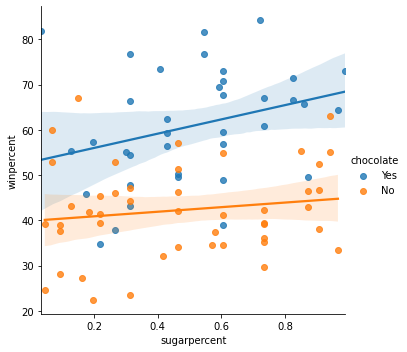

In [16]:
sns.lmplot(data=candy_data, x='sugarpercent', y='winpercent', hue='chocolate')

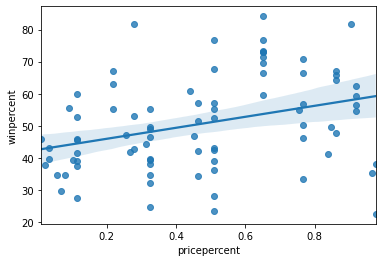

In [17]:
# Let see if popularity is related to the pricing
sns.regplot(data=candy_data, x='pricepercent', y='winpercent')

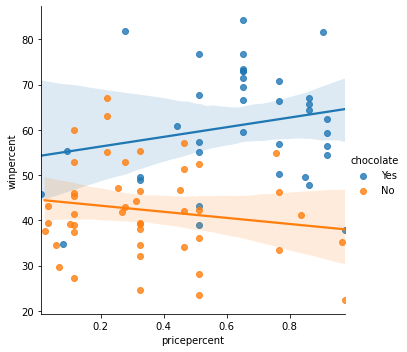

In [18]:
sns.lmplot(data=candy_data, x='pricepercent', y='winpercent', hue='chocolate')

## Conclusion:
* We can infer from the above plot that, candybars with chocolate and higher sugar are more popular as compared to bars without sugar and lower price¶
* We can also see, for candybars without chocolate, popularity decreases with increase in price wherein in case of bars with chocolate popularity increase with increase in price

## Thank You very much..

I sincerely thank you for taking time and going through my notebook. I am just starting my kaggle journey and your encouragement will be my strength in this journey. If you liked the kernel, do let me know by leaving a comment or a vote.Thank you again.
